# TM06 Clustering

## Prepare data

In [1]:
# Can download the file from ...
# !wget https://raw.githubusercontent.com/p4css/py4css/main/data/sentiment.csv -O sentiment.csv 

# OR, alternatively, create also a data/ sub-directory by this way
# !wget https://raw.githubusercontent.com/p4css/py4css/main/data/sentiment.csv -P data/

import pandas as pd
df = pd.read_csv('data/sentiment.csv')
df.head(20)

,tag,text
0,P,店家很給力，快遞也是相當快，第三次光顧啦
1,N,這樣的配置用Vista系統還是有點卡。 指紋收集器。 沒送原裝滑鼠還需要自己買，不太好。
2,P,不錯，在同等檔次酒店中應該是值得推薦的！
3,N,哎！ 不會是蒙牛乾的吧 嚴懲真凶！
4,N,空尤其是三立電視臺女主播做的序尤其無趣像是硬湊那麼多字
5,N,明明買了6本書，只到了3本，也沒有說是什麼原因，以後怎麼信的過？？？？？？？？？？？
6,P,看了一下感覺還可以
7,P,散熱還不錯，玩遊戲cpu溫度和硬碟溫度都在56以下， 速度很好，顯示卡也不錯
8,P,外觀好看，白色的自己貼紙也方便，vista執行起來速度也還不錯.屬於主流配置了。一般用用可以的
9,N,水超級小 用的時候還要先修理一下花灑 售後還說是水壓問題 說本來標配都是這樣還要自己重新換一個


### Chinese Tokenization with jieba

In [4]:
# !pip install jieba
import jieba
df['token_text'] = df['text'].apply(lambda x:list(jieba.cut(x)))
df.head(20)

Building prefix dict from the default dictionary ...
Dumping model to file cache /var/folders/j3/p4x0mssx55nd8dn903h5wdb00000gn/T/jieba.cache
Loading model cost 0.342 seconds.
Prefix dict has been built successfully.


,tag,text,token_text
0,P,店家很給力，快遞也是相當快，第三次光顧啦,"[店家, 很, 給力, ，, 快遞, 也, 是, 相當快, ，, 第三次, 光顧, 啦]"
1,N,這樣的配置用Vista系統還是有點卡。 指紋收集器。 沒送原裝滑鼠還需要自己買，不太好。,"[這樣, 的, 配置, 用, Vista, 系統, 還是, 有點, 卡, 。, , 指紋,..."
2,P,不錯，在同等檔次酒店中應該是值得推薦的！,"[不錯, ，, 在, 同等, 檔次, 酒店, 中應, 該, 是, 值得, 推薦, 的, ！]"
3,N,哎！ 不會是蒙牛乾的吧 嚴懲真凶！,"[哎, ！, , 不會, 是, 蒙牛, 乾, 的, 吧, , 嚴懲, 真凶, ！]"
4,N,空尤其是三立電視臺女主播做的序尤其無趣像是硬湊那麼多字,"[空, 尤其, 是, 三立, 電視, 臺, 女主播, 做, 的, 序, 尤其, 無趣, 像是..."
5,N,明明買了6本書，只到了3本，也沒有說是什麼原因，以後怎麼信的過？？？？？？？？？？？,"[明明, 買, 了, 6, 本書, ，, 只到, 了, 3, 本, ，, 也, 沒, 有, ..."
6,P,看了一下感覺還可以,"[看, 了, 一下, 感覺還, 可以]"
7,P,散熱還不錯，玩遊戲cpu溫度和硬碟溫度都在56以下， 速度很好，顯示卡也不錯,"[散熱, 還不錯, ，, 玩遊戲, cpu, 溫度, 和, 硬碟, 溫度, 都, 在, 56..."
8,P,外觀好看，白色的自己貼紙也方便，vista執行起來速度也還不錯.屬於主流配置了。一般用用可以的,"[外觀, 好看, ，, 白色, 的, 自己, 貼紙, 也, 方便, ，, vista, 執行..."
9,N,水超級小 用的時候還要先修理一下花灑 售後還說是水壓問題 說本來標配都是這樣還要自己重新換一個,"[水超級, 小, , 用, 的, 時候, 還要, 先, 修理, 一下, 花灑, , 售後..."


### Loading stop words

In [82]:
# !wget https://raw.githubusercontent.com/p4css/py4css/main/data/sentiment.csv -O stopwords_zh-tw.txt 
# !wget https://raw.githubusercontent.com/p4css/py4css/main/data/sentiment.csv -P data/

with open("data/stopwords_zh-tw.txt", encoding="utf-8") as fin:
    stopwords = fin.read().split("\n")[1:]
print(stopwords[:100])
print(len(stopwords))

['?', '、', '。', '“', '”', '《', '》', '！', '，', '：', '；', '？', '人民', '末##末', '啊', '阿', '哎', '哎呀', '哎喲', '唉', '我', '我們', '按', '按照', '依照', '吧', '吧噠', '把', '罷了', '被', '本', '本著', '比', '比方', '比如', '鄙人', '彼', '彼此', '邊', '別', '別的', '別說', '並', '並且', '不比', '不成', '不單', '不但', '不獨', '不管', '不光', '不過', '不僅', '不拘', '不論', '不怕', '不然', '不如', '不特', '不惟', '不問', '不只', '朝', '朝著', '趁', '趁著', '乘', '沖', '除', '除此之外', '除非', '除了', '此', '此間', '此外', '從', '從而', '打', '待', '但', '但是', '當', '當著', '到', '得', '的', '的話', '等', '等等', '地', '第', '叮咚', '對', '對於', '多', '多少', '而', '而況', '而且', '而是']
1208


### Removing Punctuations and stopwords

In [83]:
def remove_stopWords(words):
    out = []
    for word in words:
        if word not in stopwords:
            out.append(word)
    return out


import unicodedata # for removing Chinese puctuation
def remove_punc_by_unicode(words):
    out = []
    for word in words:
        if word != " " and not unicodedata.category(word[0]).startswith('P'):
            out.append(word)
    return out


In [84]:
df['cleaned'] = df['token_text'].apply(remove_stopWords)
df['cleaned'] = df['cleaned'].apply(remove_punc_by_unicode)
df


,tag,text,token_text,cleaned,cluster
0,P,店家很給力，快遞也是相當快，第三次光顧啦,"[店家, 很, 給力, ，, 快遞, 也, 是, 相當快, ，, 第三次, 光顧, 啦]","[店家, 給力, 快遞, 相當快, 第三次, 光顧]",0
1,N,這樣的配置用Vista系統還是有點卡。 指紋收集器。 沒送原裝滑鼠還需要自己買，不太好。,"[這樣, 的, 配置, 用, Vista, 系統, 還是, 有點, 卡, 。, , 指紋,...","[配置, Vista, 系統, 有點, 卡, 指紋, 收集器, 沒送, 原裝, 滑鼠, 需要...",0
2,P,不錯，在同等檔次酒店中應該是值得推薦的！,"[不錯, ，, 在, 同等, 檔次, 酒店, 中應, 該, 是, 值得, 推薦, 的, ！]","[不錯, 同等, 檔次, 酒店, 中應, 值得, 推薦]",0
3,N,哎！ 不會是蒙牛乾的吧 嚴懲真凶！,"[哎, ！, , 不會, 是, 蒙牛, 乾, 的, 吧, , 嚴懲, 真凶, ！]","[蒙牛, 乾, 嚴懲, 真凶]",0
4,N,空尤其是三立電視臺女主播做的序尤其無趣像是硬湊那麼多字,"[空, 尤其, 是, 三立, 電視, 臺, 女主播, 做, 的, 序, 尤其, 無趣, 像是...","[空, 尤其, 三立, 電視, 臺, 女主播, 做, 序, 尤其, 無趣, 像是, 硬, 湊...",0
...,...,...,...,...,...
6383,P,價效比高、記憶體大、功能全，螢幕超清晰,"[價效, 比高, 、, 記憶體, 大, 、, 功能, 全, ，, 螢幕超, 清晰]","[價效, 比高, 記憶體, 功能, 全, 螢幕超, 清晰]",0
6384,N,你太狠了… 告訴你他們不會喧譁的人，肯定是蒙牛喝多了,"[你, 太狠, 了, …, , 告訴, 你, 他們, 不會, 喧, 譁, 的, 人, ，,...","[太狠, 告訴, 喧, 譁, 人, 肯定, 蒙牛, 喝多]",0
6385,N,醫生居然買了蒙牛，我是喝呢還是不喝呢還是不喝呢？,"[ , 醫生, 居然, 買, 了, 蒙牛, ，, 我, 是, 喝, 呢, 還是, 不, 喝,...","[醫生, 買, 蒙牛, 喝, 喝, 喝]",0
6386,N,我只想說 夾蒙牛是不對的 販賣毒品是犯罪行為,"[我, 只, 想, 說, , 夾, 蒙牛, 是, 不, 對, 的, , 販賣, 毒品, ...","[只, 想, 說, 夾, 蒙牛, 販賣, 毒品, 犯罪, 行為]",0


## Feature selection

### tfidf vectorization
1. https://towardsdatascience.com/clustering-documents-with-python-97314ad6a78d
2. https://blog.csdn.net/blmoistawinde/article/details/80816179

In [12]:
doc = ['hahaha', 'heheh', 'testing']
" ".join(doc)

'hahaha heheh testing'

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
documents = [" ".join(doc) for doc in df['cleaned']]
documents[:10]

['店家 給力 快遞 相當快 第三次 光顧',
 '配置 Vista 系統 有點 卡 指紋 收集器 沒送 原裝 滑鼠 需要 買 不太好',
 '不錯 同等 檔次 酒店 中應 值得 推薦',
 '蒙牛 乾 嚴懲 真凶',
 '空 尤其 三立 電視 臺 女主播 做 序 尤其 無趣 像是 硬 湊 多字',
 '明明 買 本書 只到 說 原因 以後怎麼 信的過',
 '一下 感覺還',
 '散熱 還不錯 玩遊戲 cpu 溫度 硬碟 溫度 56 以下 速度 好 顯示 卡 不錯',
 '外觀 好看 白色 貼紙 方便 vista 執行 速度 還不錯 屬 主流 配置',
 '水超級 小 還要 先 修理 一下 花灑 售後還 說 水壓 問題 說 本來 標配 還要 重新 換一個']

### Method 1. 

In [29]:
vectorizer = TfidfVectorizer(
    ngram_range = (1, 2),
    max_df =0.2,
    token_pattern = r"(?u)\b\w+\b",
    use_idf = True
)
X = vectorizer.fit_transform(documents)
len(documents)

6388

### Model 2

#### Model 1. 

In [31]:
tfidf_model = TfidfVectorizer().fit(documents)
sparse_result = tfidf_model.transform(documents)
# print(sparse_result)
print(len(tfidf_model.vocabulary_))

11964


#### Model 2

In [32]:
tfidf_model2 = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b").fit(documents)
print(len(tfidf_model2.vocabulary_))

13060


#### Model 3

- 当然有些时候我们还是要过滤掉一些无意义的词，下面有些别的参数也可以帮助我们实现这一目的：`max_df/min_df: [0.0, 1.0]`内浮点数或正整数, 默认值=`1.0`。当设置为浮点数时，过滤出现在超过max_df/低于min_df比例的句子中的词语；正整数时,则是超过max_df句句子。这样就可以帮助我们过滤掉出现太多的无意义词语，如下面的"我"就被过滤（虽然这里“我”的排比在文学上是很重要的）。

In [33]:
# token_pattern=r"(?u)\b\w+\b", 
tfidf_model3 = TfidfVectorizer(max_df=0.01).fit(documents)  
print(len(tfidf_model3.vocabulary_))


11860


#### Model 4 filter out stop words

In [34]:
tfidf_model4 = TfidfVectorizer(max_df=0.01,
#                             token_pattern=r"(?u)\b\w+\b", 
#                                max_features = 2000,
                               stop_words=stopwords).fit(documents)
print(len(tfidf_model4.vocabulary_))


11860


#### Model 5 Only focus on some vocabs

In [35]:
words = ['給力', '不錯', '不太好', '相當快', '無趣', '還不錯']
word_dict = {w:i for i, w in enumerate(words)}
# print(word_dict)
tfidf_model5 = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b",
                               vocabulary={"我":0, "呀":1,"!":2}).fit(documents)
print(tfidf_model5.vocabulary_)
print(tfidf_model5.transform(documents).todense())

{'我': 0, '呀': 1, '!': 2}
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 ...
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


#### Model 6 bigrams

In [25]:
tfidf_model6 = TfidfVectorizer(ngram_range=(1,2), 
                               max_df=0.01).fit(documents)
print(len(tfidf_model6.vocabulary_))

48269


#### Model 6 Bigrams limited max term number

In [36]:
tfidf_model6 = TfidfVectorizer(token_pattern = r"(?u)\b\w+\b", 
                               max_features = 2000, 
                               ngram_range = (1,2), 
                               stop_words = stopwords).fit(documents)
print(tfidf_model6.vocabulary_)

{'店家': 758, '給力': 1409, '快遞': 818, '第三次': 1368, '配置': 1833, 'vista': 71, '系統': 1393, '有點': 1081, '卡': 437, '指紋': 922, '收集器': 973, '原裝': 445, '滑鼠': 1203, '需要': 1930, '買': 1644, '不太好': 148, 'vista 系統': 72, '有點 卡': 1082, '不錯': 173, '同等': 466, '檔次': 1142, '酒店': 1839, '值得': 293, '推薦': 937, '值得 推薦': 294, '蒙牛': 1504, '尤其': 714, '電視': 1928, '臺': 1477, '做': 301, '像是': 314, '硬': 1344, '湊': 1198, '明明': 1031, '本書': 1108, '說': 1621, '原因': 444, '一下': 80, '散熱': 994, '還不錯': 1798, '玩遊戲': 1260, 'cpu': 39, '溫度': 1200, '硬碟': 1345, '以下': 244, '速度': 1757, '好': 617, '顯示': 1953, '顯示 卡': 1954, '外觀': 559, '好看': 646, '白色': 1307, '方便': 1013, '執行': 539, '屬': 718, '主流': 199, '外觀 好看': 561, '執行 速度': 541, '小': 701, '還要': 1823, '先': 349, '問題': 500, '本來': 1106, '標配': 1127, '重新': 1852, '太差': 593, '知道': 1339, '星': 1035, '時': 1041, '廢話': 760, '塊': 545, '錢': 1867, '塊 錢': 546, '覺得': 1589, '牛奶': 1244, '霸氣': 1931, '牛奶 蒙牛': 1245, 'linux': 56, '根本': 1116, '裝': 1571, 'ghost': 45, '版本': 1240, 'xp': 75, '剛買': 411, '降': 1898, '100':

/Users/jirlong/opt/anaconda3/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:396: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['a', '末'] not in stop_words.
  warnings.warn(


### `transform()`: Step 2 of the method 2 

In [37]:
X = tfidf_model4.transform(documents)

In [38]:
X.shape

(6388, 11860)

## Clustering

### Evaluation

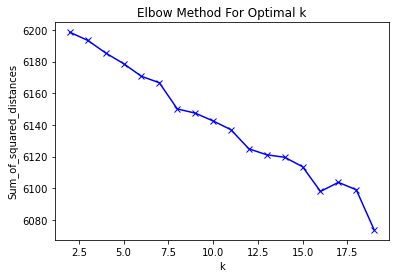

In [39]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
Sum_of_squared_distances = []
K = range(2,20)
for k in K:
   km = KMeans(n_clusters=k, max_iter=200, n_init=10)
   km = km.fit(X)
   Sum_of_squared_distances.append(km.inertia_)
plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

### Select k and Restore data

In [40]:
true_k = 8
model = KMeans(n_clusters = true_k, 
               init = 'k-means++', 
               max_iter = 200, 
               n_init = 10)
model.fit(X)

labels=model.labels_
df['cluster'] = labels
df
X.shape

(6388, 11860)

## Visualizing overall patterns


### Reduced by TruncatedSVD

In [42]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=2, n_iter=7, random_state=42)
points = svd.fit_transform(X)
points[:20]

array([[ 0.05231804,  0.02824435],
       [ 0.04636166, -0.04329032],
       [ 0.01193301, -0.00811522],
       [ 0.00016142, -0.00013531],
       [ 0.01459432, -0.01152482],
       [ 0.01037917, -0.01004575],
       [ 0.00133032, -0.00150374],
       [ 0.02300426, -0.02150665],
       [ 0.02293862, -0.02232616],
       [ 0.02299304, -0.01331872],
       [ 0.01864261, -0.02576837],
       [ 0.00092999, -0.00229986],
       [ 0.03616617, -0.0309248 ],
       [ 0.08544933, -0.04070802],
       [ 0.01437063, -0.01600148],
       [ 0.02456277, -0.01682162],
       [ 0.03788688, -0.03472228],
       [ 0.02715168, -0.00824201],
       [ 0.00465534, -0.00430276],
       [ 0.02715168, -0.00824201]])

### Dimension reduction by TSNE

In [43]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=0)
points = tsne.fit_transform(X) 
points[:20]

/Users/jirlong/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/Users/jirlong/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


array([[  59.11622   ,   66.75784   ],
       [  82.50678   ,  120.60442   ],
       [  57.14081   ,  -37.90422   ],
       [   1.5531235 ,    2.7644174 ],
       [  45.452026  ,   97.02197   ],
       [ -55.408978  ,  110.88744   ],
       [  11.672925  ,   -9.184578  ],
       [ -20.19059   ,   47.719128  ],
       [ 133.46275   ,  -75.686905  ],
       [ -61.89435   ,  -50.60146   ],
       [-147.55981   ,   24.857458  ],
       [  91.6646    ,  -24.183315  ],
       [  59.229008  ,  -70.70306   ],
       [ -47.749226  , -103.9104    ],
       [ 122.31046   ,   83.575264  ],
       [ -35.81669   ,   88.33665   ],
       [ -57.196033  ,   32.171337  ],
       [  -4.456265  ,    0.36042923],
       [ 106.709015  ,   80.39683   ],
       [  -4.4558764 ,    0.36043617]], dtype=float32)

In [44]:
df_point = pd.DataFrame(points, columns = ['x', 'y'])
df_merge = pd.concat([df, df_point], axis='columns')
df_merge

,tag,text,token_text,cleaned,cluster,x,y
0,P,店家很給力，快遞也是相當快，第三次光顧啦,"[店家, 很, 給力, ，, 快遞, 也, 是, 相當快, ，, 第三次, 光顧, 啦]","[店家, 給力, 快遞, 相當快, 第三次, 光顧]",0,59.116219,66.757843
1,N,這樣的配置用Vista系統還是有點卡。 指紋收集器。 沒送原裝滑鼠還需要自己買，不太好。,"[這樣, 的, 配置, 用, Vista, 系統, 還是, 有點, 卡, 。, , 指紋,...","[配置, Vista, 系統, 有點, 卡, 指紋, 收集器, 沒送, 原裝, 滑鼠, 需要...",0,82.506783,120.604424
2,P,不錯，在同等檔次酒店中應該是值得推薦的！,"[不錯, ，, 在, 同等, 檔次, 酒店, 中應, 該, 是, 值得, 推薦, 的, ！]","[不錯, 同等, 檔次, 酒店, 中應, 值得, 推薦]",0,57.140808,-37.904221
3,N,哎！ 不會是蒙牛乾的吧 嚴懲真凶！,"[哎, ！, , 不會, 是, 蒙牛, 乾, 的, 吧, , 嚴懲, 真凶, ！]","[蒙牛, 乾, 嚴懲, 真凶]",0,1.553123,2.764417
4,N,空尤其是三立電視臺女主播做的序尤其無趣像是硬湊那麼多字,"[空, 尤其, 是, 三立, 電視, 臺, 女主播, 做, 的, 序, 尤其, 無趣, 像是...","[空, 尤其, 三立, 電視, 臺, 女主播, 做, 序, 尤其, 無趣, 像是, 硬, 湊...",0,45.452026,97.021973
...,...,...,...,...,...,...,...
6383,P,價效比高、記憶體大、功能全，螢幕超清晰,"[價效, 比高, 、, 記憶體, 大, 、, 功能, 全, ，, 螢幕超, 清晰]","[價效, 比高, 記憶體, 功能, 全, 螢幕超, 清晰]",0,-0.036635,-6.997953
6384,N,你太狠了… 告訴你他們不會喧譁的人，肯定是蒙牛喝多了,"[你, 太狠, 了, …, , 告訴, 你, 他們, 不會, 喧, 譁, 的, 人, ，,...","[太狠, 告訴, 喧, 譁, 人, 肯定, 蒙牛, 喝多]",0,9.391043,-93.421165
6385,N,醫生居然買了蒙牛，我是喝呢還是不喝呢還是不喝呢？,"[ , 醫生, 居然, 買, 了, 蒙牛, ，, 我, 是, 喝, 呢, 還是, 不, 喝,...","[醫生, 買, 蒙牛, 喝, 喝, 喝]",0,23.044748,30.337036
6386,N,我只想說 夾蒙牛是不對的 販賣毒品是犯罪行為,"[我, 只, 想, 說, , 夾, 蒙牛, 是, 不, 對, 的, , 販賣, 毒品, ...","[只, 想, 說, 夾, 蒙牛, 販賣, 毒品, 犯罪, 行為]",0,60.474663,-36.916641


In [45]:
from bokeh.models import ColumnDataSource, Label, LabelSet, Range1d
from bokeh.plotting import figure, output_file, show
from bokeh.io import output_notebook
output_notebook()

Loading BokehJS ...

In [46]:
def generate_color(x, total):
    def color_red_blue(ctr, reverse=False):
        r = int(ctr*255)
        b = 255-int(ctr*255)
        if reverse:
            return "#%02x%02x%02x" % (b, 0, r)
        else:
            return "#%02x%02x%02x" % (r, 0, b)
    return color_red_blue(x/total)

print(generate_color(1, 6))

#2a00d5


#### bokeh.palettes
- https://docs.bokeh.org/en/latest/docs/reference/palettes.html

In [47]:
p = figure(title = "doc clustering")


colors = df_merge['cluster'].apply(lambda x:generate_color(x, true_k))

from bokeh.palettes import Magma, Inferno, Plasma, Viridis, Cividis, d3
palletes = d3['Category20'][true_k]
colors = [palletes[clu] for clu in df_merge['cluster']]
# print(colors)
p.circle(df_merge["x"], df_merge["y"], color = colors, fill_alpha=0.2, size=10)
show(p)

### Dimension reduction by PCA

(Fails due to sparse input)

In [55]:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# points = pca.fit_transform(X)

## Visualizing word freq in each cluster

### Store to dict+list for bar chart


- Using defaultdict: https://docs.python.org/3/library/collections.html

In [57]:
from collections import defaultdict, Counter
cdict = defaultdict(Counter)
for k, v in zip(df['cluster'], df['cleaned']):
    for word in v:
        cdict[k][word] += 1
for c in cdict:
    print(cdict[c].most_common(20))
    print("-"*80)

[('蒙牛', 1538), ('好', 1045), ('不錯', 789), ('買', 537), ('說', 387), ('酒店', 337), ('房間', 327), ('感覺', 318), ('喝', 313), ('外觀', 268), ('書', 252), ('喜歡', 246), ('價格', 241), ('系統', 233), ('後', 233), ('螢幕', 231), ('價效', 225), ('方便', 220), ('太', 219), ('有點', 212)]
--------------------------------------------------------------------------------
[('選擇', 63), ('太差', 49), ('齊全', 46), ('功能', 39), ('不錯', 38), ('好', 26), ('酒店', 23), ('房間', 22), ('質量', 18), ('說', 17), ('價格', 13), ('效能', 12), ('設施', 12), ('價效', 11), ('外觀', 9), ('人', 9), ('書', 8), ('買', 8), ('電池', 8), ('方便', 8)]
--------------------------------------------------------------------------------
[('網上', 37), ('好評', 31), ('買', 14), ('好', 13), ('後', 10), ('不錯', 9), ('書', 7), ('安裝', 7), ('找', 5), ('驅動', 5), ('先給', 5), ('服務', 5), ('失望', 4), ('送', 4), ('收到', 4), ('水器', 4), ('到位', 4), ('再', 4), ('價效', 3), ('售', 3)]
--------------------------------------------------------------------------------
[('小時', 63), ('分割', 39), ('槽', 39), ('不夠', 36), ('系統'

In [160]:
import pandas as pd
df1 = pd.DataFrame(list(cdict[0].most_common(5)), columns = ['word', 'n'])
df1

,word,n
0,買,263
1,說,221
2,書,204
3,感覺,159
4,螢幕,142


### Barh by seaborn

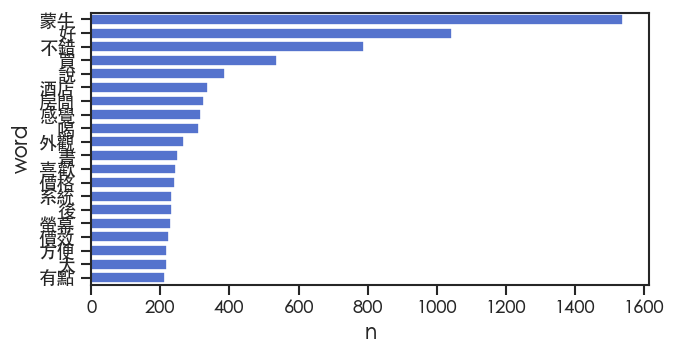

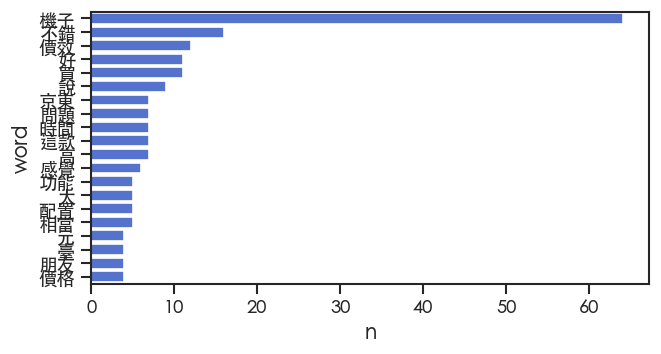

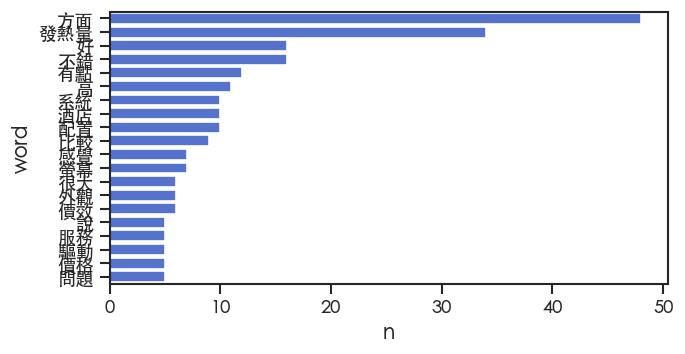

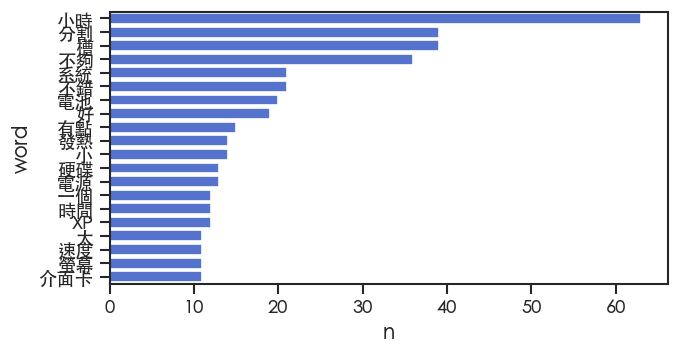

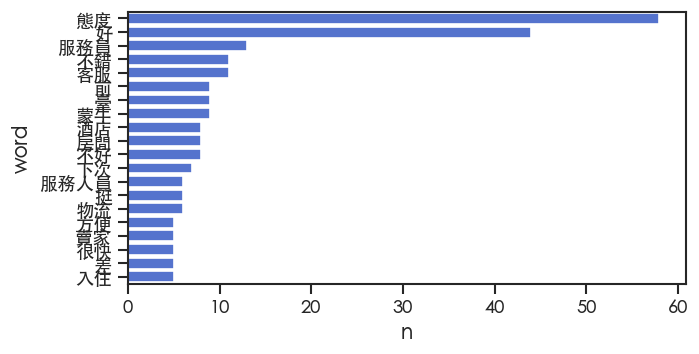

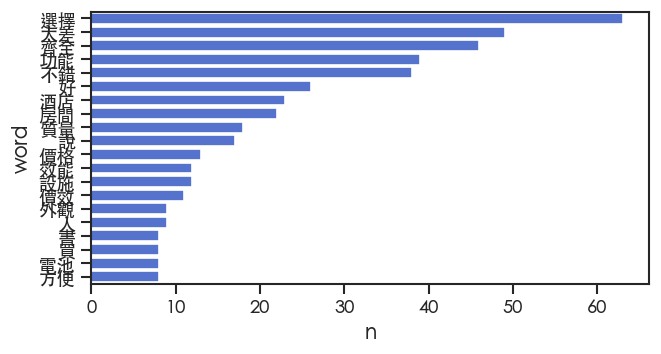

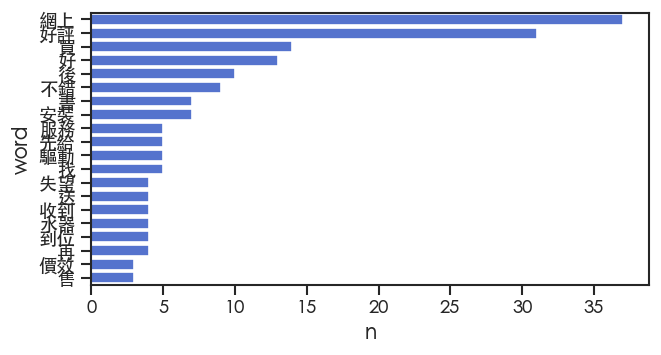

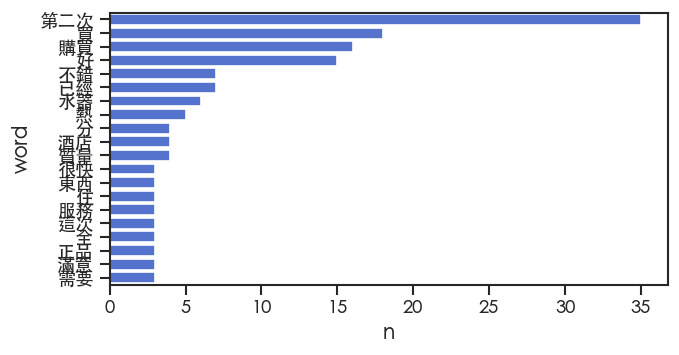

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Heiti TC']

for clu in range(true_k):
    df1 = pd.DataFrame(list(cdict[clu].most_common(20)), columns = ['word', 'n'])
    plt.figure(figsize=(6, 3), dpi=120) 
    df_data = df1.sort_values('n', ascending=False)
#     print(df_data)
    sns.barplot(x='n', 
                y='word', 
                data=df_data, 
                label='word', 
                color='royalblue',
               )

### Plot by bokeh (Fail)

Cannot plot horizontal bar

In [65]:
# from bokeh.io import show
# from bokeh.models import ColumnDataSource
# from bokeh.plotting import figure, output_file, show

In [67]:
# # output_file("topN.html")
# g = figure(title = "top N word bar")
# g.hbar(y='word',
#        right = 'n',
#        source = ColumnDataSource(df1),
#        height = 0.5)
  
# # displaying the model
# show(g)


### Visualized by wordcloud (Fail)

Cannot show Chinese

```python
# !pip install wordcloud
# from wordcloud import WordCloud

# # plt.figure(figsize=(8, 6), dpi=300) 
# wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate("我是 我是 台灣 台灣 人")
# plt.figure(figsize=(8, 6), dpi=90) 
# plt.imshow(wordcloud, interpolation="bilinear")
# plt.rcParams['font.family'] = ['Heiti TC']
# plt.axis("off")
# plt.show()
```

In [ ]:
{
    "doc1":["w1", "w2", "w3", "w4", "w5", "w1", "w2"],